In [31]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Clustering: DBSCAN

### Cargar datos

In [3]:
df = pd.read_csv("hyg_sample.csv")
X = df[["ci", "log_lum"]]
print(X)

        ci  log_lum
0    1.021   1.1288
1    0.614   0.2792
2    1.112   1.4672
3    0.909   1.0468
4    0.580  -3.6920
..     ...      ...
749  1.050   1.2424
750  1.210   1.5828
751  1.378   2.0512
752  1.069   1.7968
753  1.101   0.9260

[754 rows x 2 columns]


### Recomendado: escalar las columnas para que sean comparables 

In [6]:
# Por defecto, StandardScaler convierte cada valor al z-score por columna
# z = (x - mu)/std, donde x es un dato, mu y std son la media y desv. est. de la columna
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Aplicar DBSCAN

In [107]:
# eps: radio de la vecindad (en unidades escaladas en este caso)
# min_sample: mínimo número de puntos en una vecindad de un core point
# labels nos da el clustering (0, 1, 2, etc), y -1 son noise points
db = DBSCAN(eps=0.5, min_samples=10).fit(X)
labels = db.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print("Número de clusters identificados: %d" % n_clusters_)
print("Número de noise points (outliers): %d" % n_noise_)

Número de clusters identificados: 2
Número de noise points (outliers): 8


### Graficar el resultado (scatter plot)

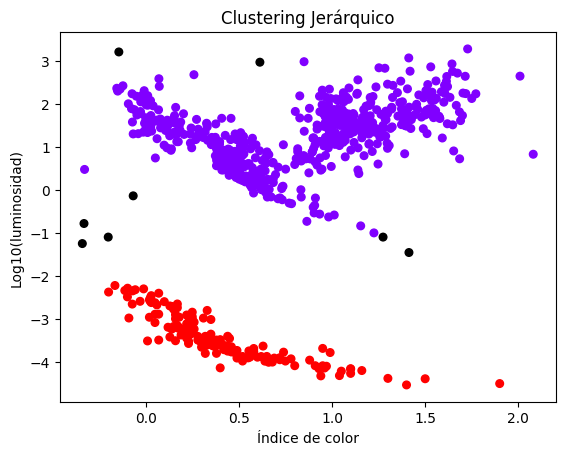

In [109]:
# Mapear etiquetas a colores, pero dejas los outliers (-1) en negro
cmap = mpl.colormaps.get_cmap("rainbow")
norm = mpl.colors.Normalize(vmin=0, vmax=labels.max())
colors = [cmap(norm(x)) if x != -1 else "black" for x in labels]
# Graficar
plt.scatter(df['ci'], df['log_lum'], c=colors, s=30)
plt.title('Clustering Jerárquico')
plt.xlabel('Índice de color')
plt.ylabel('Log10(luminosidad)')
plt.show()

#### Cosas a probar
- variar epsilon
- variar min_samples